## Multi Criteria Analysis


#### Import Neccessary Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

#### Load the Data

In [22]:
df = pd.read_csv('retail_multicriteria.csv')
df.head()

,Country,Description,Quantity,Price,Revenue
0,Nigeria,Product_001,870,95.80,83346.19
1,USA,Product_001,3782,300.44,1136267.21
2,Australia,Product_001,476,54.49,25936.09
3,Germany,Product_001,3454,302.55,1045014.37
4,Canada,Product_001,140,15.19,2126.51


#### Aggregate Data

In [23]:
df.head()

grouped = df.groupby("Description").agg(
    total_sales = ("Quantity", 'sum'),
    total_revenue = ('Revenue', "sum")
).reset_index()

grouped

,Description,total_sales,total_revenue
0,Product_001,8722,2292690.37
1,Product_002,11457,1169899.00
2,Product_003,8787,1996905.15
3,Product_004,12852,3475321.75
4,Product_005,9642,1102118.78
5,Product_006,13816,4203148.67
6,Product_007,14978,3106976.71
7,Product_008,12058,3009257.07
8,Product_009,15167,3250684.68
9,Product_010,11417,3494797.57


#### Create ABC Reusable Function

In [24]:
def abc_classification(series):
    df_temp = pd.DataFrame(
        {'metrics': series})
    
    df_temp = df_temp.sort_values(
        by = "metrics",
        ascending= False
    )
    df_temp['cummulative_percentage'] = (df_temp['metrics'].cumsum() / df_temp['metrics'].sum())

    def classifier(values):
        if values <= 0.8:
            return 'A'
        elif values <= 0.95:
            return 'B'
        return 'C'
    
    df_temp['ABC'] = df_temp['cummulative_percentage'].apply(classifier)

    return df_temp['ABC']
print("Function abc_classification successfully created")

Function abc_classification successfully created


### ABC on Sales

In [25]:
sales_df = grouped.copy()
sales_df = sales_df.sort_values('total_sales', ascending= False)

sales_df['Sales_abc'] = abc_classification(sales_df['total_sales'])

sales_df

,Description,total_sales,total_revenue,Sales_abc
91,Product_092,19440,3988266.98,A
80,Product_081,18248,4307218.73,A
56,Product_057,18046,4890489.50,A
83,Product_084,17955,5806879.91,A
60,Product_061,17503,5295789.09,A
35,Product_036,17479,3535532.03,A
49,Product_050,17290,2772776.31,A
62,Product_063,17276,5364969.23,A
42,Product_043,16956,3969977.12,A
45,Product_046,16951,4482046.12,A


### ABC on Revenue

In [26]:
revenue_df = grouped.copy()
revenue_df = revenue_df.sort_values('total_revenue', ascending= False)

revenue_df['Revenue_abc'] = abc_classification(sales_df['total_revenue'])

revenue_df

,Description,total_sales,total_revenue,Revenue_abc
61,Product_062,16107,6551435.69,A
83,Product_084,17955,5806879.91,A
62,Product_063,17276,5364969.23,A
38,Product_039,15065,5351998.21,A
99,Product_100,14988,5351557.82,A
60,Product_061,17503,5295789.09,A
78,Product_079,16169,5285204.98,A
52,Product_053,13852,5234102.84,A
85,Product_086,14670,5156916.86,A
57,Product_058,14346,5113123.12,A


### Merge Results

In [27]:
# to merge the result for sales 

final_df = grouped.merge(sales_df[['Description', 'Sales_abc']], on = 'Description')

final_df = final_df.merge(revenue_df[['Description', 'Revenue_abc']], on = 'Description')

# to create a product mix along the line

final_df['Product_mix'] = final_df['Sales_abc'] + final_df['Revenue_abc']

final_df

,Description,total_sales,total_revenue,Sales_abc,Revenue_abc,Product_mix
0,Product_001,8722,2292690.37,C,B,CB
1,Product_002,11457,1169899.00,A,C,AC
2,Product_003,8787,1996905.15,B,B,BB
3,Product_004,12852,3475321.75,A,A,AA
4,Product_005,9642,1102118.78,B,C,BC
5,Product_006,13816,4203148.67,A,A,AA
6,Product_007,14978,3106976.71,A,A,AA
7,Product_008,12058,3009257.07,A,A,AA
8,Product_009,15167,3250684.68,A,A,AA
9,Product_010,11417,3494797.57,A,A,AA


In [28]:
# just trynna check the unique values we've got in product mix column
print(final_df['Product_mix'].unique())
print(final_df['Product_mix'].nunique())


<ArrowStringArray>
['CB', 'AC', 'BB', 'AA', 'BC', 'CC', 'BA', 'AB', 'CA']
Length: 9, dtype: str
9


### Visualizations

#### Count of Product Mix

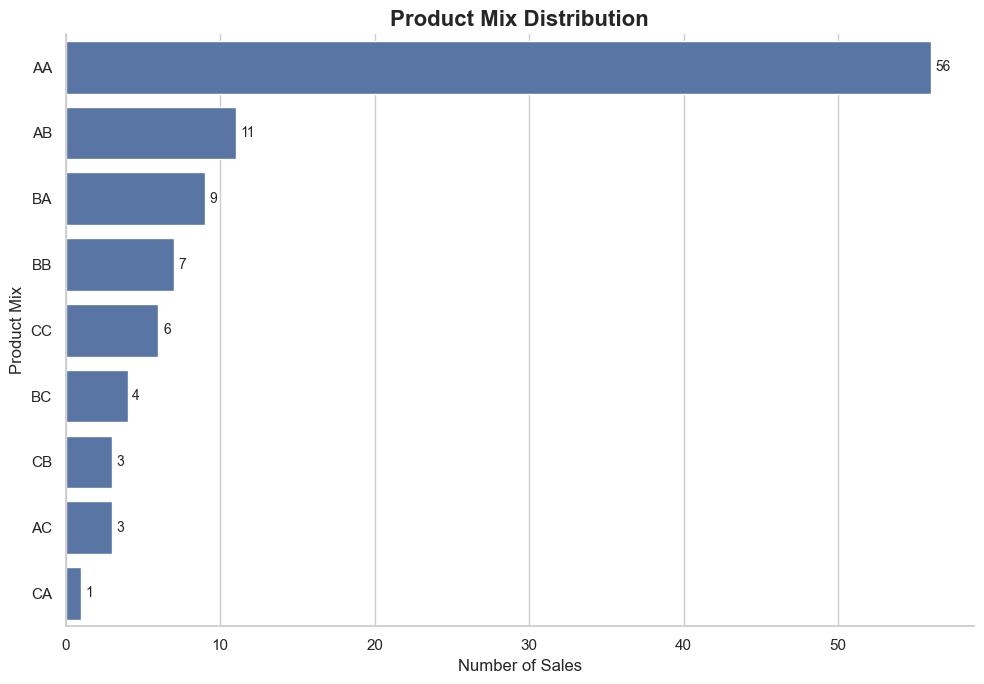

In [29]:
plt.figure(figsize=(10, 7))

sns.set_theme(style="whitegrid")

ax = sns.countplot(
    data=final_df,
    y='Product_mix',
    order=final_df['Product_mix'].value_counts().index
)

# Add count labels
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_width())}',
        (p.get_width() + 0.3,
         p.get_y() + p.get_height() / 2),
        ha='left',
        va='center',
        fontsize=10
    )

plt.title('Product Mix Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Number of Sales', fontsize=12)
plt.ylabel('Product Mix', fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

#### Revenue by Product Mix

In [30]:
final_df["Product_mix"].value_counts()

Product_mix
AA    56
AB    11
BA     9
BB     7
CC     6
BC     4
CB     3
AC     3
CA     1
Name: count, dtype: int64

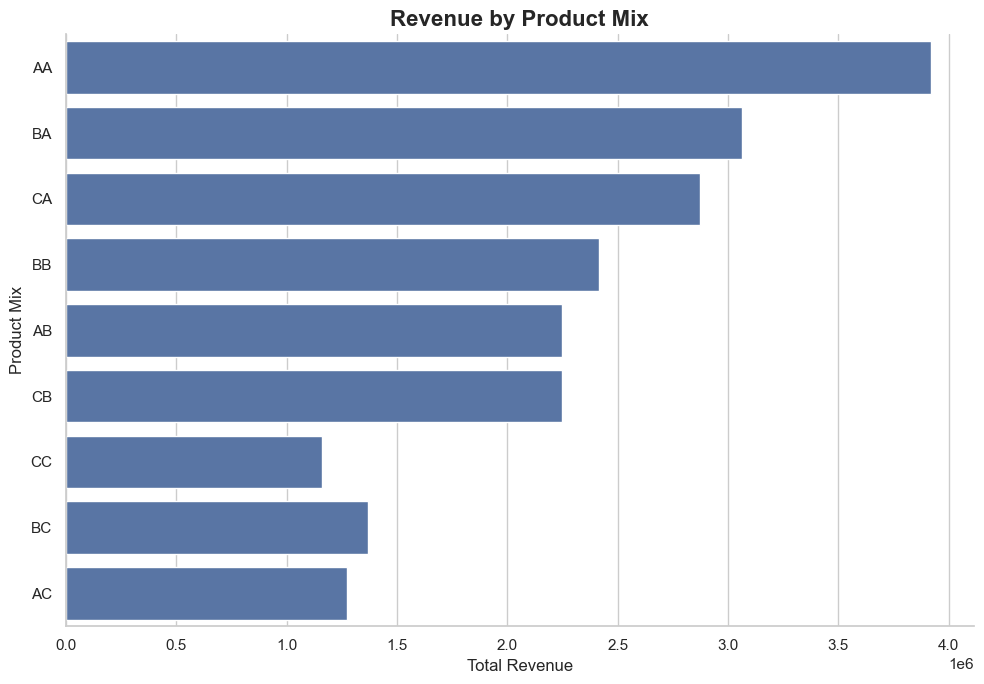

In [31]:
plt.figure(figsize=(10, 7))

sns.set_theme(style="whitegrid")

sns.barplot(
    y='Product_mix',
    x='total_revenue',
    data=final_df.sort_values('total_revenue', ascending=False),
    errorbar=None
)

plt.title('Revenue by Product Mix', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue', fontsize=12)
plt.ylabel('Product Mix', fontsize=12)

sns.despine()

plt.tight_layout()
plt.show()

### Store-Level Analysis

In [32]:
by_store = (

    df.groupby(
        ["Country",
         "Description"]
    )

    .agg(
        total_sales=("Quantity","sum"),
        total_revenue=("Revenue","sum")
    )

    .reset_index()

)

# to display all the rows in the dataframe

pd.set_option('display.max_rows', None)


by_store

,Country,Description,total_sales,total_revenue
0,Australia,Product_001,476,25936.09
1,Australia,Product_002,1194,185786.29
2,Australia,Product_003,985,118418.49
3,Australia,Product_004,2898,107807.16
4,Australia,Product_005,1488,456739.14
5,Australia,Product_006,3853,371825.89
6,Australia,Product_007,3808,1000791.75
7,Australia,Product_008,2072,179864.38
8,Australia,Product_009,2288,748823.80
9,Australia,Product_010,2783,1236125.97
